In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# read the data
df = pd.read_csv("C:\\Users\\Narendra Kumar\\OneDrive\\Pictures\\Screenshots\\Zomato-Data-Analysis\\Zomato data .csv")
print(df)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB
None


In [5]:
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


In [6]:
def rate_column(val):
    val = str(val).split('/')
    val = val[0]
    return float(val)
df['rate'] = df['rate'].apply(rate_column)
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB
None


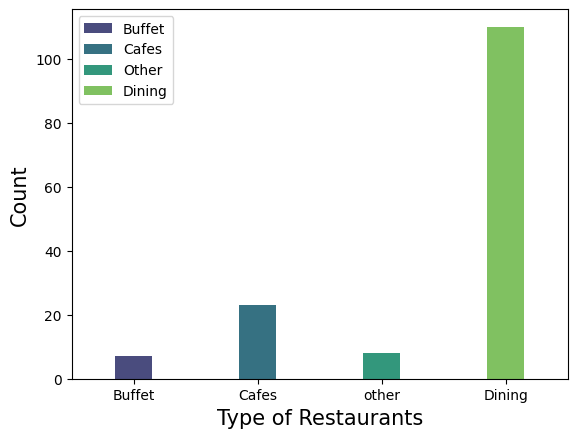

In [8]:
# What popular restaurant categories can be identified from the listed_in (type) column?
sns.countplot(x='listed_in(type)',data=df,width=0.3,palette="viridis",hue='listed_in(type)')
plt.xlabel('Type of Restaurants',color='black',fontsize=15)
plt.ylabel('Count',color='black',fontsize=15)
plt.legend(['Buffet','Cafes','Other','Dining'])
plt.show()

Conclusion: Dining Restaurant is the most popular category in the listed_in (type) column.

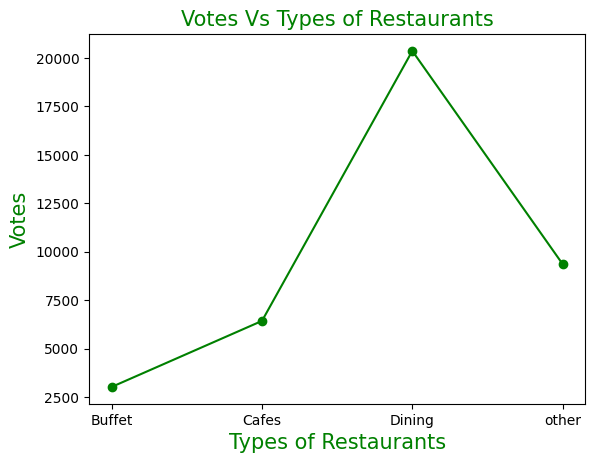

In [9]:
# How many votes does each category receive?
count_votes = df.groupby('listed_in(type)')['votes'].sum()
res = pd.DataFrame({'votes':count_votes})
plt.plot(res,color='g',marker='o')
plt.title("Votes Vs Types of Restaurants",color='g',fontsize=15)
plt.xlabel('Types of Restaurants',color='g',fontsize=15)
plt.ylabel('Votes',color='g',fontsize=15)
plt.show()

Conclusion: Dining Restaurants have received the highest number of votes.

In [10]:
# Which restaurant has the highest number of votes?
max_votes = df.iloc[df['votes'].idxmax()]
print(max_votes)

name                           Empire Restaurant
online_order                                 Yes
book_table                                    No
rate                                         4.4
votes                                       4884
approx_cost(for two people)                  750
listed_in(type)                            other
Name: 38, dtype: object


Conclusion: Empire Restaurant has the highest number of votes (4884) among all restaurants in the dataset.

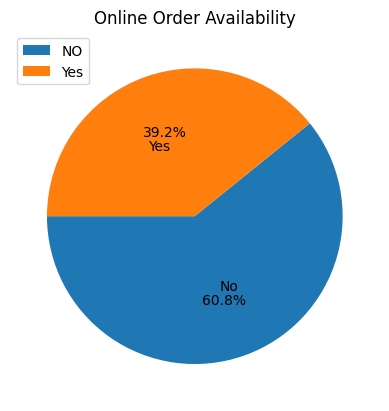

In [11]:
# How many restaurants provide online ordering services?
counts = df['online_order'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%',labeldistance=0.5,startangle=180)
plt.title("Online Order Availability")
plt.legend(['NO','Yes'],loc=2)
plt.show()

Conclusion: 60.8% of restaurants do not provide online ordering, while only 39.2% of restaurants accept online orders.

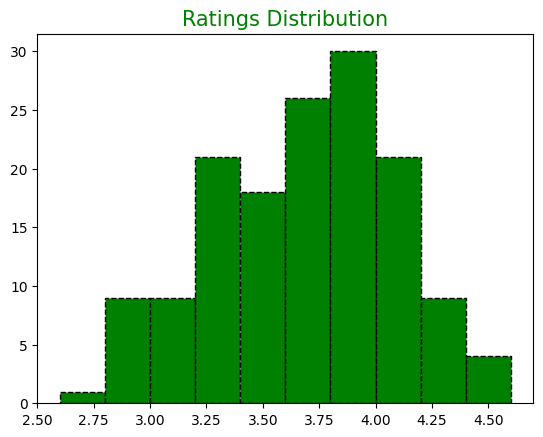

In [12]:
#  What is the distribution of ratings in the rate column?
plt.hist(df['rate'],color='g',edgecolor='black',linestyle='--')
plt.title('Ratings Distribution',color='g',fontsize=15)
plt.show()

Conclusion: The majority of restaurants received ratings ranging from 3.5 to 4.

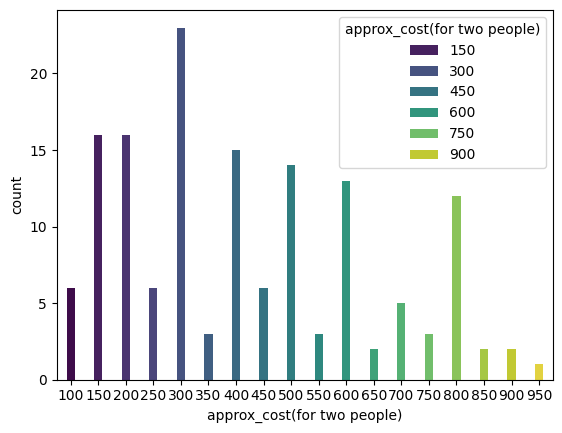

In [13]:
#  What price range is most preferred by customers according to the approx_cost (for two people) column?
two_people=df['approx_cost(for two people)']
sns.countplot(x=two_people,data=df,width=0.3,palette="viridis",hue=two_people)
plt.show()

Conclusion: ₹300 is the most preferred price range among customers.

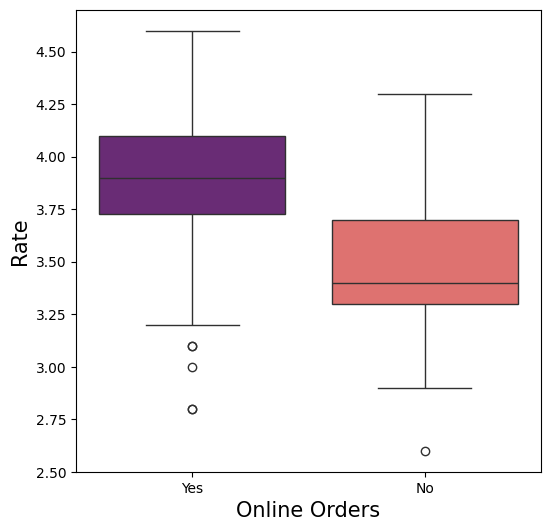

In [14]:
#  How do the ratings compare between restaurants that accept online orders and those that do not?”
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df,palette="magma",hue='online_order')
plt.xlabel('Online Orders',color='black',fontsize=15)
plt.ylabel('Rate',color='black',fontsize=15)
plt.show()

Conclusion: Online Order = 3.4
            Offline Order = 3.9
        
       So, Restaurants that accept online orders tend to have slightly higher ratings compared to restaurants that do not accept online orders.

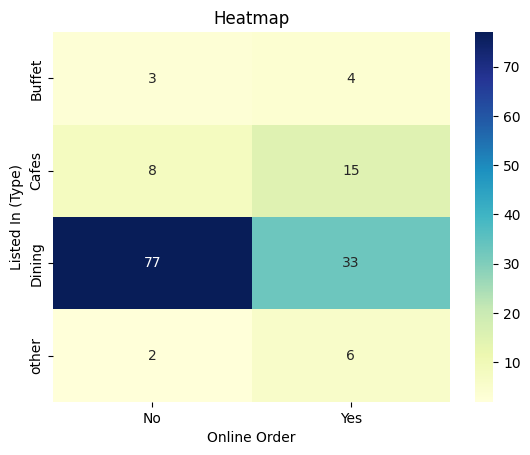

In [15]:
#  Find the relationship between order mode (online_order) and restaurant type (listed_in(type)).
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

Conclusion: Dining restaurants are the most common type, but many of them do not accept online orders. In contrast, cafes are more likely to accept online orders compared to other restaurant types.

In [16]:
df.to_csv("Clean-Zomato-Data.csv", index=False)

In [17]:
import os
os.getcwd()

'c:\\Users\\Narendra Kumar\\OneDrive\\Pictures\\Screenshots\\Zomato-Data-Analysis'